# Lab 01 — Feature engineering and feature selection

*Check the tools, understand the data, build features, and choose among them*

**Goal.** Confirm that the course environment works, run the data quality checklist, engineer new features and encode them inside a leakage-safe pipeline, see why scaling changes distance, and select features without letting the answer leak in.

**Data.** `all_datasets/titanic_dataset.csv`, `all_datasets/breast_cancer_dataset.csv`, `all_datasets/student_performance_dataset.csv`

**Reading.** Chapter 2 (Your Python Toolkit), Chapter 3 (Understanding and Preparing Data), Chapter 5 (distance and scaling), Chapter 8 (feature selection)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab01/` — environment versions, missing-value shares, survival by title, feature-set comparison, lasso coefficients, distance matrices

**How much is scaffolded?** Fully worked. Run every cell and read the output. The Try-it task at the end asks you to add a feature of your own.

**Workflow**

1. Part A — Environment check and a first look at the data
2. Part B — Feature engineering
3. Part C — Scaling changes the geometry
4. Part D — Feature selection without leakage
5. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab01/`.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, pairwise_distances, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Notebooks live in all_experiments/, so the course folder is one level up.
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"

RESULTS = PROJECT_ROOT / "results" / "lab01"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — Environment check and a first look at the data

Every result in this course depends on four packages. Print their versions once, at the top, so that if a number ever changes between two runs you can rule out the environment first.

In [2]:
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
pandas: 3.0.3
Matplotlib: 3.11.0
scikit-learn: 1.9.0


The Titanic file has one row per passenger and a column `Survived` that is 1 if the passenger lived. Before any feature is built, four questions have to be answered from the table itself: how big is it, what type is each column, what is missing, and how balanced is the label.

In [3]:
df = pd.read_csv(DATA / "titanic_dataset.csv")

print("shape:", df.shape)
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nSurvival rate:\n", df["Survived"].value_counts(normalize=True))

shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

A bar chart makes the gaps easier to compare than a column of numbers. Only three columns have any, and one of them is mostly empty.

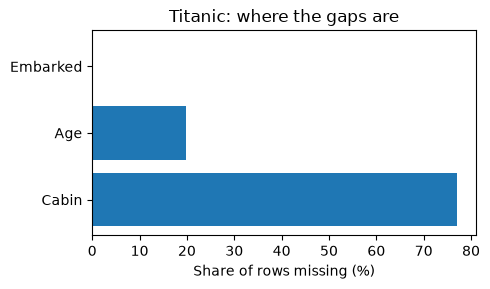

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(5, 3))
plt.barh(missing.index, missing.values * 100)
plt.xlabel("Share of rows missing (%)")
plt.title("Titanic: where the gaps are")
plt.tight_layout()
plt.savefig(RESULTS / "titanic_where_the_gaps_are.png", dpi=160, bbox_inches="tight")
plt.show()

**What the output shows.** All four packages import cleanly. 891 passengers, 12 columns; `Cabin` is missing for 77% of rows, `Age` for 20%, `Embarked` for 2 rows. Only 38% survived, so a model that always says *did not survive* is already 62% accurate; anything built later must beat that.

## Part B — Feature engineering

Feature engineering means building inputs the model cannot see on its own. Four new columns follow. `FamilySize` and `IsAlone` come from two counts; `Title` is pulled out of the name with a regular expression; `LogFare` tames a long right tail. Every one is built from information that would be known before the outcome, which is the test each new feature must pass.

In [5]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Other")
df["LogFare"] = np.log1p(df["Fare"])

print(df[["Name", "Title", "FamilySize", "IsAlone", "Fare", "LogFare"]].head())
print("\nTitle counts:\n", df["Title"].value_counts())

                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone     Fare   LogFare  
0        0   7.2500  2.110213  
1        0  71.2833  4.280593  
2        1   7.9250  2.188856  
3        0  53.1000  3.990834  
4        1   8.0500  2.202765  



Title counts:
 Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


Grouping the label by the new columns shows whether they carry signal. Two of them clearly do.

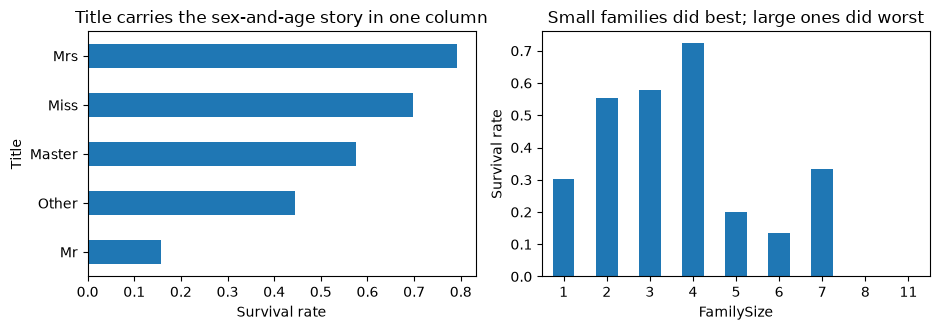

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
df.groupby("Title")["Survived"].mean().sort_values().plot.barh(ax=axes[0])
axes[0].set_xlabel("Survival rate")
axes[0].set_title("Title carries the sex-and-age story in one column")
df.groupby("FamilySize")["Survived"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylabel("Survival rate")
axes[1].set_title("Small families did best; large ones did worst")
plt.tight_layout()
plt.savefig(RESULTS / "small_families_did_best_large_ones_did_worst.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** `Master` (young boys) survived far more often than `Mr`, and married women more often than single ones; the title compresses sex, age, and status into one column. Survival rises from lone travellers to families of two to four, then collapses for large families.

Does the engineering help a model? The only fair test is the same model, the same split, with and without the new columns. Preprocessing lives inside a pipeline: imputation, scaling, and encoding are learned from the training rows only, and reapplied unchanged to validation rows.

In [7]:
def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

y = df["Survived"]
feature_sets = {
    "raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
    "raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
                         ["Pclass", "Sex", "Embarked", "Title"]),
}

for name, (num_cols, cat_cols) in feature_sets.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    model = Pipeline([
        ("preprocess", make_preprocess(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=2000)),
    ]).fit(X_train, y_train)
    auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    print(f"{name:18s} validation ROC AUC = {auc:.3f}")

raw columns        validation ROC AUC = 0.842
raw + engineered   validation ROC AUC = 0.872


**What to look for.** The engineered set scores higher. It is the same logistic regression: the gain came entirely from giving it better columns, which is usually cheaper than a more complex model.

**What the output shows.** `Master` (boys) survive far more often than `Mr`, and `Mrs` more often than `Miss`; families of two to four survive at over 50% while lone travellers and families of five or more fall to 30% and below. Fed to the same logistic regression on the same split, the engineered columns lift validation ROC AUC by about three points. That is the cheapest improvement in the course: no new model, just better columns.

## Part C — Scaling changes the geometry

Many models (nearest neighbours, clustering, SVMs, neural networks) work by measuring distances between rows. The breast-cancer table has 30 measurements per tumour in very different units: `area` columns run into the thousands, `smoothness` is a fraction below one.

In [8]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
feature_cols = [c for c in cancer.columns if c not in {"id", "diagnosis", "Unnamed: 32"}]
X_cancer = cancer[feature_cols]

three = ["area_mean", "texture_mean", "smoothness_mean"]
print(X_cancer[three].describe().loc[["mean", "std"]].round(3))

      area_mean  texture_mean  smoothness_mean
mean    654.889        19.290            0.096
std     351.914         4.301            0.014


Compute the distance between the first five tumours twice: once on the raw numbers, once after standardizing every column to mean 0 and standard deviation 1. Side-by-side heatmaps make the comparison immediate; dark cells are close pairs.

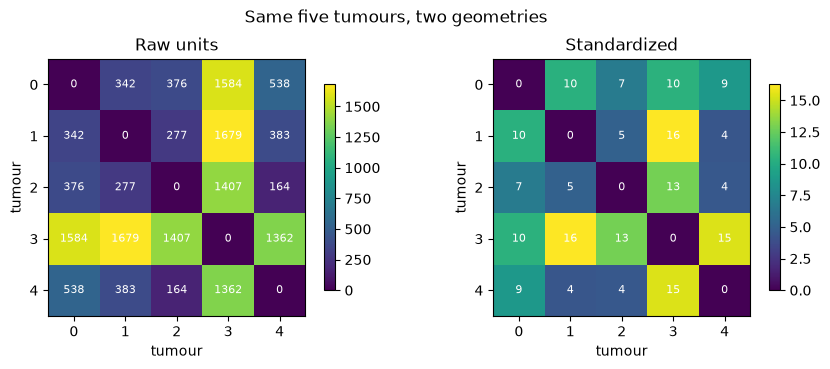

In [9]:
raw = pairwise_distances(X_cancer.iloc[:5], metric="euclidean")
X_scaled = StandardScaler().fit_transform(X_cancer)
scaled = pairwise_distances(X_scaled[:5], metric="euclidean")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, matrix, title in [(axes[0], raw, "Raw units"), (axes[1], scaled, "Standardized")]:
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("tumour")
    ax.set_ylabel("tumour")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Same five tumours, two geometries")
plt.tight_layout()
plt.savefig(RESULTS / "same_five_tumours_two_geometries.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** In raw units the closest pair is tumours 3 and 5; after scaling it is 2 and 5. Nothing about the tumours changed, only the measuring stick. Any distance-based model would give different answers on the two versions, which is why the scaler sits inside the pipeline.

**What the output shows.** Raw distances are in the hundreds and thousands because the `area` columns dwarf everything else; in raw units the distance is really just a difference in area. After scaling every feature counts equally and the closest pair changes from (3, 5) to (2, 5). Distance-based models see whichever geometry you hand them.

## Part D — Feature selection without leakage

Student Performance describes 649 secondary-school students with 32 possible features and a final grade `G3`. The task is to predict `G3` *at enrolment*, so the two earlier term grades `G1` and `G2` do not exist yet and are left out. With 30 candidate columns, which ones matter?

In [10]:
students = pd.read_csv(DATA / "student_performance_dataset.csv")
print("shape:", students.shape, " missing:", students.isna().sum().sum(),
      " duplicates:", students.duplicated().sum())

target = "G3"
leaky = ["G1", "G2"]
X_s = students.drop(columns=[target] + leaky)
y_s = students[target]
s_num = X_s.select_dtypes(include="number").columns.tolist()
s_cat = X_s.select_dtypes(exclude="number").columns.tolist()
print(len(s_num), "numeric and", len(s_cat), "text features available at enrolment")

Xs_train, Xs_valid, ys_train, ys_valid = train_test_split(X_s, y_s, test_size=0.25, random_state=42)

shape: (649, 33)  missing: 0  duplicates: 0
13 numeric and 17 text features available at enrolment


Three feature sets are compared with the same ridge regression. `SelectKBest` keeps the ten columns most correlated with the grade; the lasso penalty shrinks weak coefficients all the way to zero and so selects on its own. Both selectors sit *inside* the pipeline, after encoding, so they only ever see training rows. The fourth run adds `G2` back on purpose, to show what leakage looks like.

In [11]:
def evaluate(pipeline, X_tr, X_va, label):
    pipeline.fit(X_tr, ys_train)
    mae = mean_absolute_error(ys_valid, pipeline.predict(X_va))
    print(f"{label:32s} validation MAE = {mae:.3f} grade points")
    return mae

results = {}
results["all 30 features"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "all 30 features")

results["SelectKBest, k=10"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("select", SelectKBest(f_regression, k=10)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "SelectKBest, k=10")

lasso = Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Lasso(alpha=0.1)),
])
results["lasso (selects itself)"] = evaluate(lasso, Xs_train, Xs_valid, "lasso (selects itself)")

leak_num = s_num + ["G2"]
results["all 30 + G2 (leakage)"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(leak_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train.assign(G2=students.loc[Xs_train.index, "G2"]),
    Xs_valid.assign(G2=students.loc[Xs_valid.index, "G2"]), "all 30 + G2 (leakage)")

all 30 features                  validation MAE = 2.181 grade points
SelectKBest, k=10                validation MAE = 2.139 grade points
lasso (selects itself)           validation MAE = 2.077 grade points
all 30 + G2 (leakage)            validation MAE = 0.762 grade points


lasso kept 19 of 56 encoded columns


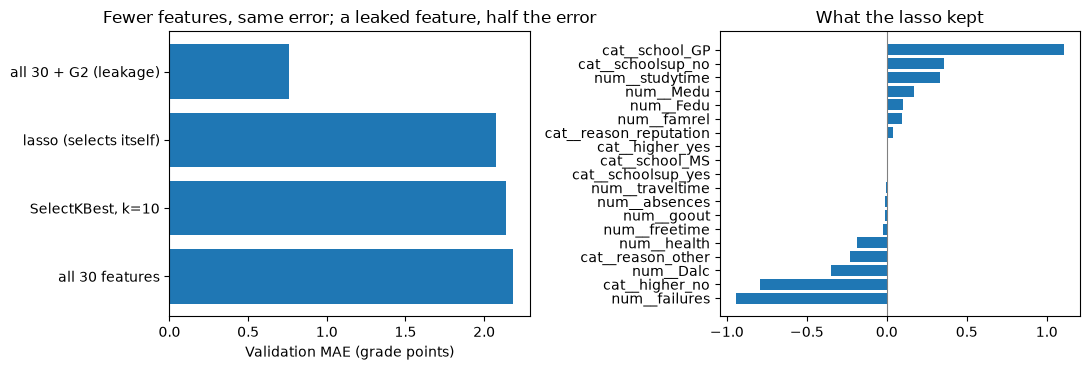

In [12]:
coefs = pd.Series(lasso.named_steps["model"].coef_,
                  index=lasso.named_steps["preprocess"].get_feature_names_out())
kept = coefs[coefs != 0].sort_values()
print(f"lasso kept {len(kept)} of {len(coefs)} encoded columns")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(list(results), list(results.values()))
axes[0].set_xlabel("Validation MAE (grade points)")
axes[0].set_title("Fewer features, same error; a leaked feature, half the error")
axes[1].barh(kept.index, kept.values)
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].set_title("What the lasso kept")
plt.tight_layout()
plt.savefig(RESULTS / "what_the_lasso_kept.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Ten selected columns do about as well as all thirty, and the lasso, which chose for itself, does slightly better with a third of the encoded columns: most of the table is noise for this task. The leaked column cuts the error by two thirds, which looks like a triumph and is actually a broken experiment, because `G2` would not exist at enrolment. The columns the lasso trusts most are which `school` the student attends, past `failures`, not wanting `higher` education, weekday alcohol (`Dalc`), and `studytime`, and every one of them makes sense to a teacher.

**What the output shows.** All 30 enrolment features: MAE 2.18 grade points. The ten best by correlation: 2.14. The lasso, keeping 19 of 56 encoded columns: 2.08. So most of the table is noise for this task, and a selector chosen inside the pipeline does no harm and a little good. Adding `G2` drops the MAE to 0.76, a result that would be impossible to deliver at enrolment because the column does not exist yet: that is what leakage looks like in a number.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [13]:
pd.DataFrame({
    "package": ["numpy", "pandas", "matplotlib", "scikit-learn"],
    "version": [np.__version__, pd.__version__, matplotlib.__version__, sklearn.__version__],
}).to_csv(RESULTS / "environment.csv", index=False)
missing.rename("share_missing").to_csv(RESULTS / "missing_values.csv")
df.groupby("Title")["Survived"].agg(["count", "mean"]).to_csv(RESULTS / "survival_by_title.csv")
pd.Series(results, name="validation_mae").rename_axis("feature_set").round(3).to_csv(RESULTS / "feature_selection.csv")
kept.rename("lasso_coefficient").round(3).to_csv(RESULTS / "lasso_coefficients.csv")
pd.DataFrame(raw).round(2).to_csv(RESULTS / "distances_raw.csv", index=False)
pd.DataFrame(scaled).round(2).to_csv(RESULTS / "distances_scaled.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['distances_raw.csv', 'distances_scaled.csv', 'environment.csv', 'feature_selection.csv', 'lasso_coefficients.csv', 'missing_values.csv', 'same_five_tumours_two_geometries.png', 'small_families_did_best_large_ones_did_worst.png', 'survival_by_title.csv', 'titanic_where_the_gaps_are.png', 'what_the_lasso_kept.png']


## Try it yourself

Engineer one more Titanic feature (the first letter of `Cabin`, or fare per family member) and check whether the validation ROC AUC in Part B improves. Then rerun Part D with `k=5` and `k=20` and see whether the error changes.

Attempt it in the cell below before reading the solution.

In [14]:
# Your work here


### One solution

A cabin-deck feature for Titanic, then the two other `k` values for the student grades.

In [15]:
# Part 1: the deck is the first letter of Cabin; missing cabins become their own category.
df["Deck"] = df["Cabin"].str[0].fillna("none")
print(df.groupby("Deck")["Survived"].agg(["count", "mean"]).round(2))

num_cols = ["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"]
for label, cat_cols in {"raw + engineered": ["Pclass", "Sex", "Embarked", "Title"],
                        "raw + engineered + Deck": ["Pclass", "Sex", "Embarked", "Title", "Deck"]}.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    model = Pipeline([("preprocess", make_preprocess(num_cols, cat_cols)),
                      ("model", LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
    print(f"{label:26s} validation ROC AUC = {roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]):.3f}")

# Part 2: other selection sizes for the student grades.
for k in [5, 10, 20]:
    evaluate(Pipeline([("preprocess", make_preprocess(s_num, s_cat)),
                       ("select", SelectKBest(f_regression, k=k)),
                       ("model", Ridge(alpha=1.0))]), Xs_train, Xs_valid, f"SelectKBest, k={k}")

      count  mean
Deck             
A        15  0.47
B        47  0.74
C        59  0.59
D        33  0.76
E        32  0.75
F        13  0.62
G         4  0.50
T         1  0.00
none    687  0.30
raw + engineered           validation ROC AUC = 0.872
raw + engineered + Deck    validation ROC AUC = 0.868
SelectKBest, k=5                 validation MAE = 2.134 grade points
SelectKBest, k=10                validation MAE = 2.139 grade points
SelectKBest, k=20                validation MAE = 2.125 grade points


**What it shows.** Passengers with a recorded cabin survived far more often than those without (a recorded cabin mostly means first class), so `Deck` carries real signal, but most of it is already in `Pclass` and `LogFare`; the ROC AUC moves by less than a point, and on 223 validation rows that is noise. A feature can be informative and still add nothing, which is why the test is always the model's validation score, not the group table. For the student grades, five, ten, and twenty selected columns all land within 0.02 grade points of each other: the error curve is flat across a wide range of `k`, so the exact number matters far less than keeping the selector inside the pipeline.